## Imports

In [1]:
import numpy as np
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import spearmanr
import copy
import matplotlib as mpl
import json

In [2]:
lasso_or_knn = "knn"

## Load scores and plotting metadata

In [3]:
df = pd.read_csv("/home/jovyan/pert-bench-fusion-paper/results/scores/essential_lfc.csv", index_col=0)

In [4]:
with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

method_map = {
    k.replace("HEAD_TYPE", lasso_or_knn).replace("CELL_LINE", "K-562"): v
    for k, v in fig_index["essential_lfc"].items()
}
model_type_palette = fig_index['genes_model_type_palette']
hue_order = fig_index['genes_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])
mpl.rcParams.update({
    "axes.grid": False,
    "ytick.minor.visible": False,
    "xtick.minor.visible": False,
    "ytick.left": True,
})

# Metric correlations

In [5]:
df_viz = df[
    df["name"].isin(method_map)
    & (df["cell_line"] == "K-562")
    & (df["name"] != "Experimental error (quantile 0.9)")
    & (df["name"] != "no change baseline")
].copy()
df_viz['family'] = df_viz['name'].apply(lambda x: method_map[x][1])
df_viz = df_viz[df_viz['family'] != "Positive Control"]
df_viz = df_viz[df_viz['family'] != "Negative Control"]

## Multi-cell line plot

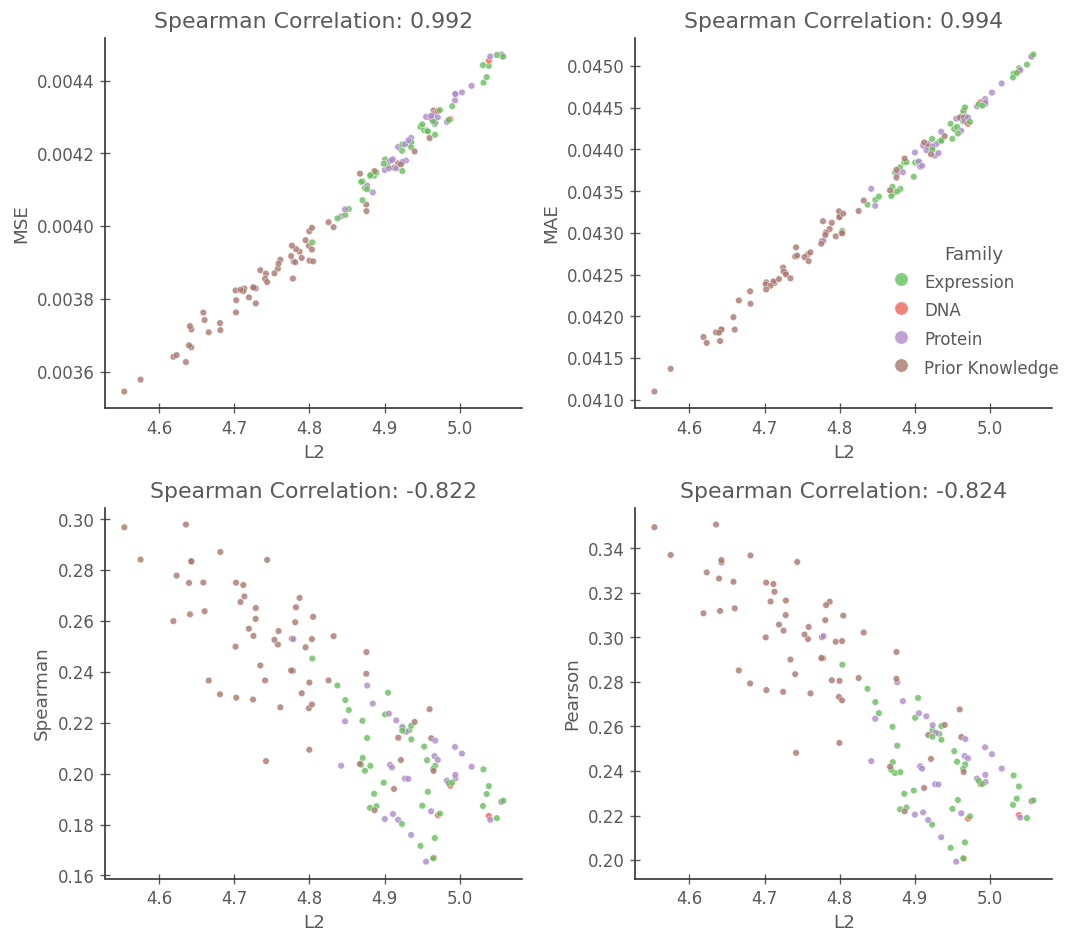

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
metric_names = ['MSE', 'MAE', 'Spearman', 'Pearson']

hue_order = present_hues = [
    h for h in hue_order if h in df_viz["family"].unique()
]

for i, cur_ax in enumerate(ax.ravel()):
    # We set legend=True for the first plot only to 'grab' the handles/labels
    sns.scatterplot(
        data=df_viz, x='L2', y=metric_names[i], 
        ax=cur_ax, s=16, alpha=0.8, hue='family', hue_order=hue_order,
        palette=model_type_palette, legend=(i == 0)
    )
    a = df_viz['L2'].to_numpy()
    b = df_viz[metric_names[i]].to_numpy()
    res = spearmanr(a, b)
    cur_ax.set_title(f'Spearman Correlation: {res.statistic:.3f}')

# 1. Grab handles and labels from the first axis (where legend=True)
handles, labels = ax[0, 0].get_legend_handles_labels()

# 2. Remove the internal legend from the first plot
ax[0, 0].get_legend().remove()

# 3. Create the figure-level legend at the upper right
# bbox_to_anchor coordinates are (x, y)
leg = fig.legend(
    handles, labels, 
    loc='upper right', 
    bbox_to_anchor=(.9, 0.75), 
    title='Family',
    labelcolor="0.35",
)
plt.setp(leg.get_title(), color='0.35')

# 4. Control the dot size in the legend separately
for handle in leg.legend_handles:
    handle.set_markersize(8.0)  # Adjust 50.0 to your preferred legend dot size

# 5. Adjust layout to make room for the legend on the right
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("fig_A11.pdf")